In [1]:
import pandas as pd

df = pd.read_csv('/content/spam.csv', encoding='latin-1')
df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [2]:
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
encoder = LabelEncoder()

# Encode the 'Category' column
df['Category_encoded'] = encoder.fit_transform(df['Category'])

print("Encoded categories:")
print(df[['Category', 'Category_encoded']].head())

Encoded categories:
  Category  Category_encoded
0      ham                 0
1      ham                 0
2     spam                 1
3      ham                 0
4      ham                 0


In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer()

# Apply TF-IDF to the 'Message' column
X = tfidf_vectorizer.fit_transform(df['Message'])

print("Shape of TF-IDF feature matrix (X):")
print(X.shape)

Shape of TF-IDF feature matrix (X):
(5572, 8745)


In [4]:
from sklearn.model_selection import train_test_split

y = df['Category_encoded']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (4457, 8745)
Shape of X_test: (1115, 8745)
Shape of y_train: (4457,)
Shape of y_test: (1115,)


In [5]:
from sklearn.linear_model import LogisticRegression

# Initialize Logistic Regression model
model = LogisticRegression(solver='liblinear', random_state=42)

# Train the model
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [6]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Compute confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Print the metrics
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# Print the confusion matrix
print("\nConfusion Matrix:")
print(conf_matrix)

Accuracy: 0.9623
Precision: 1.0000
Recall: 0.7181
F1-Score: 0.8359

Confusion Matrix:
[[966   0]
 [ 42 107]]


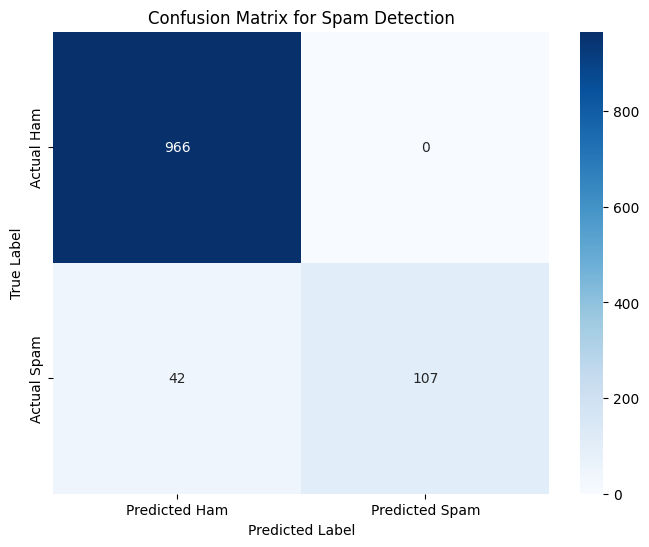

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

# Re-load data, encode, vectorize, and train model to ensure variables are defined
df = pd.read_csv('/content/spam.csv', encoding='latin-1')

encoder = LabelEncoder()
df['Category_encoded'] = encoder.fit_transform(df['Category'])

tfidf_vectorizer = TfidfVectorizer()
X = tfidf_vectorizer.fit_transform(df['Message'])

y = df['Category_encoded']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression(solver='liblinear', random_state=42)
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Compute confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Ham', 'Predicted Spam'],
            yticklabels=['Actual Ham', 'Actual Spam'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Spam Detection')
plt.show()